In [1]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from pathlib import Path
from dotenv import load_dotenv

/var/folders/yd/_m8_59617mj2h9bql97_j64r0000gn/T/ipykernel_3785/2047418069.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader, DirectoryLoader


In [2]:
# load the api keys
load_dotenv()

True

In [3]:
# create the llm and embedding model

llm = ChatOpenAI(model="gpt-5-mini")

embedder = OpenAIEmbeddings(model="text-embedding-3-small",
                            dimensions=1024) # 1536

In [4]:
# load the docs from source

loader = DirectoryLoader(path=Path("./cleaned-transcripts/").as_posix(),
                         loader_cls=TextLoader,
                         show_progress=True)

docs = loader.load()

100%|██████████| 3/3 [00:00<00:00, 1280.83it/s]


In [5]:
docs[0].page_content[0:1000]

"Pakistan, Ahmedabad, Patna, Dheradoon, Subodh, where are you from? I am from Dheradoon too.\nYou are from Kharrawala, you are from Kharwala, I am from Miawala\nCome on, perfect\nOkay, let's begin\nFirst of all, I will introduce myself\nHas anyone seen me or taken any course of mine before?\nAnyone? Yes or no please?\nOkay, fine\nNo worries, let me tell you about myself\nI am Ajay, I belong to Uttarakhand\nAnd I have been working with CampusX for the last two years\nI am working on the Data Analytics and AI part on CampusX\nAnd in the last two years, I have delivered multiple courses like\nOLAMA, Data Analytics, Mentorship Program, Gemini, Power BI and many more\nAnd I will be taking most of your AI Pulse sessions\nRight? So currently, I am working with CampusX\nAnd I am doing my doctorate in frugal AI\nNow, coming to the session\nToday's session is going to be on AI Pulse\nWhat are we going to do in this session?\nIn this session, we are going to talk about\nWhat are we going to do in

In [6]:
# chunk the text

chunker = RecursiveCharacterTextSplitter(chunk_size=500,
                                         chunk_overlap=50)

chunks = chunker.split_documents(docs)

In [7]:
print(f"Chunks: {len(chunks)}")

Chunks: 542


In [9]:
# vector store

vs = Chroma(collection_name="rag_demo",
            embedding_function=embedder,
            persist_directory=Path("./saved-embeddings").as_posix())

# add docs

vs.add_documents(chunks)

['fed54d8c-cdc8-430b-b50b-cdb75465f02f',
 '78ba0073-647c-4a06-8aa0-df0505b4164d',
 '8ef0629c-2d4c-4e16-93dd-352319ad8926',
 'a6119c6b-807e-42d4-9102-9d68d450f3dd',
 'fb5eb762-4305-4f16-bd29-5ee5845047eb',
 '48b578ab-1b3a-4658-a267-edbffe8b0463',
 '92ce40fe-5c06-4677-b980-dc83a56b606b',
 '43036589-8db0-4e07-8336-4baf00ecfced',
 'fdfb3d22-2d57-4789-b4c1-8cc8480ee980',
 '236b9407-908a-4d0b-b9ad-d60f652a4cf7',
 'fa63b8bc-235f-453d-9fdd-768f8e2fe799',
 'e66600ed-9751-4b4f-8f06-7d76e803e560',
 '5b7edf67-6909-4a99-b63b-53cf103cd965',
 '8857e799-2287-40d5-b01f-4770c7edbd5d',
 '5089cba7-cf24-400f-a1cd-ef0adcac9c7d',
 '6bec2446-ea99-46e6-a18e-3b328cc7635e',
 'bc901996-8ae9-48a5-81ca-eb0232b71938',
 '9ee325fa-c7b2-43f4-b899-684a207d133c',
 '11d7f9fc-d763-431d-8494-66ab5006ed7a',
 'fa12a50d-0d62-46f5-844e-c4ea4dab56e0',
 '5cac5669-3f09-49f4-bd36-61c1b411097e',
 '5cd57735-b302-4859-aced-baed2cfbbf2f',
 'e575e37a-7408-43b6-9a06-47085a570c73',
 'f3ea245c-477d-4ed6-84c3-14f24761f679',
 'edfa71d1-3d51-

In [10]:
# create the retriever

retriever = vs.as_retriever(search_kwargs={"k":3})

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict

In [15]:
class RAGState(TypedDict):
    
    query: str 
    retrieved_docs: list[Document]
    context: str 
    prompt: ChatPromptTemplate
    response: str

In [16]:
def retrieve(state: RAGState) -> dict:
    query = state["query"]
    retrieved_docs = retriever.invoke(query)
    
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    return {"retrieved_context":retrieved_docs,
            "context":context}

In [17]:
def augmentation(state: RAGState) -> dict:

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant. Answer the user query
                      based on the given context only. If you do not know the answer
                      say I don't know. Do not add any preamble to the response"""),
        ("human", "context: {context}\n\nquery: {query}")
    ])
    
    return {"prompt": prompt}

In [18]:
from langchain_core.output_parsers import StrOutputParser

In [19]:
def generation(state: RAGState) -> dict:
    
    query = state["query"]
    context = state["context"]
    prompt = state["prompt"]
    
    rag_chain = prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context":context, "query":query})
    
    return {"response":response}

In [20]:
# create the graph
graph_builder = StateGraph(RAGState)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("augmentation", augmentation)
graph_builder.add_node("generation", generation)

graph_builder.add_edge(START,"retrieve")
graph_builder.add_edge("retrieve","augmentation")
graph_builder.add_edge("augmentation","generation")
graph_builder.add_edge("generation",END)

graph = graph_builder.compile()

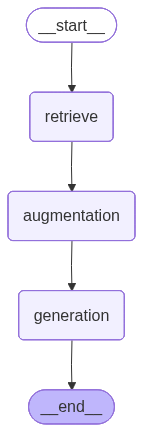

In [21]:
graph

In [32]:
result = graph.invoke({"query": "how much fine was imposed on the lawyer who used fake evidences from chatgpt"})

In [33]:
print(result["response"])

Around $5,000.


In [31]:
result["context"]

"Launching their IPO\nOkay?\nSo, early June 2026\nthe artificial intelligence industry\nhas taken a very turn\nyou can say, a very crazy turn\nWhat was the turn?\nThat two very dominant companies in the AI firm\nin the AI landscape\nOpenAI and Entropic\nthey have filed their IPO\nRight?\nMeans, these companies\nthey are planning to move public\nCheck it\nThe IPO filed by OpenAI\nhas been filed at a valuation of 1 trillion dollars\nAnd the IPO filed by Entropic\nhas been filed at a valuation of 965 billion dollars\n\nSo, this is the news\nNow, let's do one thing\nLet's deep dive this news\nLet's do its post-mortem\nRight?\nFirst of all, let's understand\nthat these companies\nAI Labs\nRight?\nThese AI Labs have been existing for a long time\nSo, why is the need to file IPO now?\nOkay?\nIf I talk about OpenAI\nOpenAI is a very old AI Lab\nNow, why is it filing IPO?\nOkay?\nSo, what are the reasons?\nIs it a catalyst?\nRight?\nBecause of which\nthese companies are filing their IPO\nOkay?\